In [1]:
!pip install scipy matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
mat_data=sio.loadmat(r'D:\Study\BSC\7th Semester\CSE 4100 - Project or Thesis whith Seminar Part I\Hyperspectral Imgae processing\HSI-Thesis\data\Indian_pines.mat')
print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])


In [6]:
hsi= mat_data['indian_pines_corrected']
print("Shape of HSI:", hsi.shape)

Shape of HSI: (145, 145, 200)


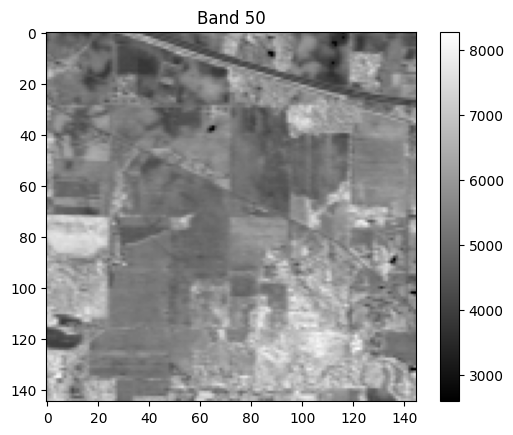

In [7]:
band_number = 50

plt.imshow(hsi[:, :, band_number], cmap='gray')
plt.title(f'Band {band_number}')
plt.colorbar()
plt.show()

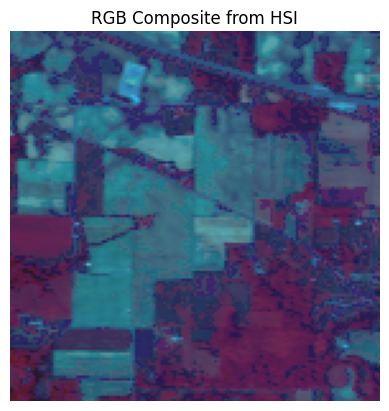

In [8]:
# Select 3 bands for RGB visualization
red_band = 60
green_band = 30
blue_band = 10

rgb = np.stack([
    hsi[:, :, red_band],
    hsi[:, :, green_band],
    hsi[:, :, blue_band]
], axis=2)

# Normalize for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb)
plt.title("RGB Composite from HSI")
plt.axis('off')
plt.show()

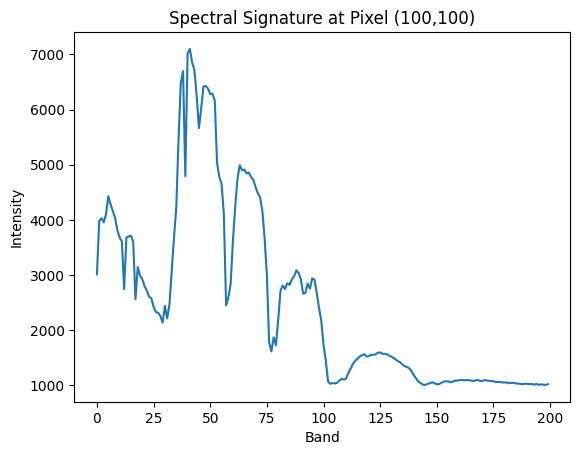

In [9]:
x = 100
y = 100

pixel_spectrum = hsi[x, y, :]

plt.plot(pixel_spectrum)
plt.title(f"Spectral Signature at Pixel ({x},{y})")
plt.xlabel("Band")
plt.ylabel("Intensity")
plt.show()

In [10]:
gt_data = sio.loadmat(r'D:\Study\BSC\7th Semester\CSE 4100 - Project or Thesis whith Seminar Part I\Hyperspectral Imgae processing\HSI-Thesis\data\Indian_pines_gt.mat')

print(gt_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])


In [11]:
gt = gt_data['indian_pines_gt']
print("Ground Truth Shape:", gt.shape)

Ground Truth Shape: (145, 145)


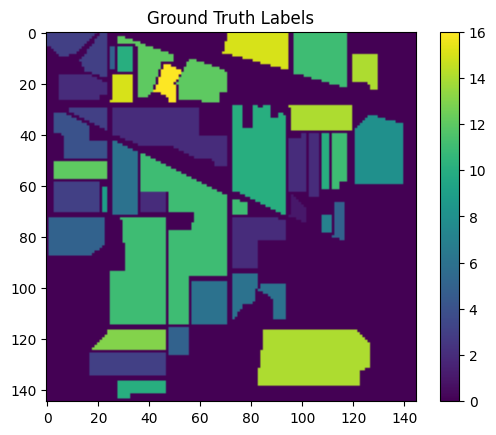

In [12]:
plt.imshow(gt)
plt.title("Ground Truth Labels")
plt.colorbar()
plt.show()

In [13]:
classes = np.unique(gt)

print("All labels:", classes)

# Remove background (0)
classes = classes[classes != 0]

num_classes = len(classes)

print("Number of classes:", num_classes)

All labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Number of classes: 16


In [14]:
num_samples = np.count_nonzero(gt)

print("Number of samples:", num_samples)

Number of samples: 10249
